<a href="https://colab.research.google.com/github/MiguelPartosa/Thesis-FOS-BinaryClass-WSD/blob/main/Combined_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Models & Libraries

In [1]:
!pip install transformers
!pip install openpyxl
# !pip install gradio

In [2]:
# Importing stock ml libraries
import warnings
warnings.simplefilter('ignore')
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn import metrics
import transformers
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from transformers import DistilBertTokenizer, DistilBertModel
import logging
logging.basicConfig(level=logging.ERROR)
from transformers import pipeline #cbert
from torch import cuda

In [3]:
unmasker = pipeline('fill-mask', model='GianTan/CBERTo')
unmasker("Hello I'm a [MASK] model.")

Device set to use cuda:0


[{'score': 0.017744775861501694,
  'token': 457,
  'token_str': 'sentence',
  'sequence': "hello i'm a sentence model."},
 {'score': 0.013290438801050186,
  'token': 1461,
  'token_str': 'given',
  'sequence': "hello i'm a given model."},
 {'score': 0.010848678648471832,
  'token': 4051,
  'token_str': 'story',
  'sequence': "hello i'm a story model."},
 {'score': 0.009323698468506336,
  'token': 3482,
  'token_str': 'text',
  'sequence': "hello i'm a text model."},
 {'score': 0.009105573408305645,
  'token': 1241,
  'token_str': 'list',
  'sequence': "hello i'm a list model."}]

In [4]:
tokenizer = DistilBertTokenizer.from_pretrained('GianTan/CBERTo',truncation=True, do_lower_case=False)
cbertmodel = DistilBertModel.from_pretrained("GianTan/CBERTo")

In [5]:
test = tokenizer('Murag mag bata nis Gian.', return_tensors='pt')
test

{'input_ids': tensor([[   2,    1,  223,  770, 4073,    1,   20,    3]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}

In [6]:
test_output = cbertmodel(input_ids=test['input_ids'], attention_mask=test['attention_mask'])
test_output

BaseModelOutput(last_hidden_state=tensor([[[ 1.8262, -2.2653, -0.2164,  ..., -0.3576,  0.7976,  0.1592],
         [ 0.1707, -0.2825,  0.3335,  ...,  0.9750,  1.2135,  1.2772],
         [-1.1447,  0.3449, -0.0371,  ..., -0.7239,  1.3636, -1.6204],
         ...,
         [-1.5133, -1.6592,  0.0718,  ...,  0.8302,  1.3838, -0.4917],
         [-1.5697, -0.8247, -2.1634,  ..., -0.4481,  0.8399, -1.4725],
         [-1.5261, -0.4124, -0.6070,  ...,  0.5469, -1.1056, -0.0184]]],
       grad_fn=<NativeLayerNormBackward0>), hidden_states=None, attentions=None)

In [7]:
# Hyperparameters for CBERT

MAX_LEN = 256
TRAIN_BATCH_SIZE = 128
VALID_BATCH_SIZE = 128
EPOCHS = 14
LEARNING_RATE = 4e-05

In [8]:
train_df = pd.read_excel("Train_Set_WLabels.xlsx")
test_df = pd.read_excel("Test_Set_WLabels.xlsx")

In [9]:
fosTrain_df = train_df
fosTest_df = test_df

In [10]:
fosTrain_df = fosTrain_df.rename(columns={"Is FOS": "is_fos"})
fosTest_df = fosTest_df.rename(columns={"Is FOS": "is_fos"})

In [11]:
class FOS_Classification(Dataset):

    def __init__(self, dataframe, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.data = dataframe
        self.text = dataframe.Usage
        self.targets = self.data.is_fos
        self.max_len = max_len

    def __len__(self):
        return len(self.text)

    def __getitem__(self, index):
        text = str(self.text[index])
        text = " ".join(text.split())

        inputs = self.tokenizer.encode_plus(
            text,
            None,
            add_special_tokens=True,
            max_length=self.max_len,
            truncation=True,
            pad_to_max_length=True,
            return_token_type_ids=True
        )
        ids = inputs['input_ids']
        mask = inputs['attention_mask']
        token_type_ids = inputs["token_type_ids"]


        return {
            'ids': torch.tensor(ids, dtype=torch.long),
            'mask': torch.tensor(mask, dtype=torch.long),
            'token_type_ids': torch.tensor(token_type_ids, dtype=torch.long),
            'targets': torch.tensor(self.targets[index], dtype=torch.float)
        }

In [12]:
training_set = FOS_Classification(fosTrain_df, tokenizer, MAX_LEN)
testing_set = FOS_Classification(fosTest_df, tokenizer, MAX_LEN)

In [13]:
train_params = {'batch_size': TRAIN_BATCH_SIZE,
                'shuffle': True,
                'num_workers': 0
                }

test_params = {'batch_size': VALID_BATCH_SIZE,
                'shuffle': True,
                'num_workers': 0
                }

training_loader = DataLoader(training_set, **train_params)
testing_loader = DataLoader(testing_set, **test_params)

In [14]:
device = 'cuda' if cuda.is_available() else 'cpu'

In [15]:
# Creating the customized model, by adding a drop out and a dense layer on top of distil bert to get the final output for the model.

class BertClass(torch.nn.Module):
    def __init__(self):
        super(BertClass, self).__init__()
        self.l1 = DistilBertModel.from_pretrained('GianTan/CBERTo')
        self.pre_classifier = torch.nn.Linear(768, 768)
        self.dropout = torch.nn.Dropout(0.3)

        self.pre_classifier2 = torch.nn.Linear(768, 768)
        self.dropout2 = torch.nn.Dropout(0.3)

        self.classifier = torch.nn.Linear(768,1)

    def forward(self, input_ids, attention_mask, token_type_ids):
        output_1 = self.l1(input_ids=input_ids, attention_mask=attention_mask)
        hidden_state = output_1[0]
        pooler = hidden_state[:, 0]
        pooler = self.pre_classifier(pooler)
        pooler = torch.nn.Tanh()(pooler)
        pooler = self.dropout(pooler)
        pooler = self.pre_classifier2(pooler)
        pooler = torch.nn.Tanh()(pooler)
        pooler = self.dropout2(pooler)


        output = self.classifier(pooler)
        return output.squeeze(1)


model1 = BertClass()
model1.to(device)

BertClass(
  (l1): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30000, 768, padding_idx=0)
      (position_embeddings): Embedding(256, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linear(in_feat

In [16]:
def loss_fn(outputs, targets):
    return torch.nn.BCEWithLogitsLoss()(outputs, targets)

In [17]:
optimizer = torch.optim.Adam(params =  model1.parameters(), lr=LEARNING_RATE)

In [18]:
def train(epoch):
    model1.train()
    for _,data in tqdm(enumerate(training_loader, 0)):
        ids = data['ids'].to(device, dtype = torch.long)
        mask = data['mask'].to(device, dtype = torch.long)
        token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
        targets = data['targets'].to(device, dtype = torch.float)

        outputs = model1(ids, mask, token_type_ids)

        optimizer.zero_grad()
        loss = loss_fn(outputs, targets)
        if _%5000==0:
            print(f'Epoch: {epoch}, Loss:  {loss.item()}')

        loss.backward()
        optimizer.step()

In [19]:
for epoch in range(EPOCHS):
    train(epoch)

0it [00:00, ?it/s]

Epoch: 0, Loss:  0.7013704776763916


11it [00:26,  2.41s/it]
1it [00:01,  1.19s/it]

Epoch: 1, Loss:  0.5320531725883484


11it [00:25,  2.31s/it]
1it [00:01,  1.06s/it]

...

11it [00:25,  2.28s/it]
1it [00:01,  1.08s/it]

Epoch: 12, Loss:  0.02569984644651413


11it [00:25,  2.28s/it]
1it [00:01,  1.09s/it]

Epoch: 13, Loss:  0.21587902307510376


11it [00:25,  2.28s/it]


In [20]:
def test_model(item):
  input_text = item
  encoded_text = tokenizer.encode_plus(
      input_text,
      None,
      add_special_tokens=True,
      max_length=MAX_LEN,
      pad_to_max_length=True,
      return_token_type_ids=True
  )

  # Convert the input to tensors
  input_ids = torch.tensor(encoded_text['input_ids']).unsqueeze(0)
  input_mask = torch.tensor(encoded_text['attention_mask']).unsqueeze(0)
  segment_ids = torch.tensor(encoded_text['token_type_ids']).unsqueeze(0)

  # Move tensors to the device
  input_ids = input_ids.to(device)
  input_mask = input_mask.to(device)
  segment_ids = segment_ids.to(device)

  # Make predictions
  with torch.no_grad():
      outputs = model1(input_ids, input_mask, segment_ids)

  # Apply sigmoid activation function
  outputs = torch.sigmoid(outputs)

  # Convert the outputs to numpy array
  outputs = outputs.cpu().detach().numpy()

  return outputs

In [21]:
#  from the validation function, let me see the actual string being passed and not just the number or tensor conversion

def validation(testing_loader):
    model1.eval()
    fin_targets=[]
    fin_outputs=[]

    with torch.no_grad():
        for _, data in tqdm(enumerate(testing_loader, 0)):
            ids = data['ids'].to(device, dtype = torch.long)
            mask = data['mask'].to(device, dtype = torch.long)
            token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
            targets = data['targets'].to(device, dtype = torch.float)
            outputs = model1(ids, mask, token_type_ids)
            fin_targets.extend(targets.cpu().detach().numpy().tolist())
            fin_outputs.extend(torch.sigmoid(outputs).cpu().detach().numpy().tolist())

    return fin_outputs, fin_targets

In [22]:
outputs, targets = validation(testing_loader)

final_outputs = np.array(outputs) >= 0.9

print(final_outputs)
print(targets)

3it [00:02,  1.10it/s]

[ True False False False False False  True False  True False False  True
 False False False False False False False  True False False  True False
 False  True False False False False  True False  True False  True False
  True  True  True  True False False False  True  True  True  True  True
 False False False False False False False False False  True  True  True
 False False  True False False False False  True  True  True False False
  True False False  True False False  True  True False  True False False
  True  True False False False False False False False  True False  True
 False False False False  True  True  True False False False False  True
  True False  True  True False False  True False False False  True  True
 False  True False False False False  True  True  True False  True False
  True False  True  True  True  True False False False False  True False
 False False False False False  True False False False  True False  True
  True  True False  True False False  True  True Fa

In [23]:
y_pred_cb = np.array(targets)
y_true_cb = np.array(final_outputs)

accuracy = accuracy_score(y_true_cb, y_pred_cb)
print(f'Accuracy Score: {accuracy:.6f}')

precision = precision_score(y_true_cb, y_pred_cb)
print(f'Precision Score: {precision:.6f}')

recall = recall_score(y_true_cb, y_pred_cb)
print(f'Recall Score: {recall:.6f}')

score_dat = f1_score(y_true_cb, y_pred_cb)
print(f'F1 Score: {score_dat:.6f}')

Accuracy Score: 0.866460
Precision Score: 0.739130
Recall Score: 0.991667
F1 Score: 0.846975


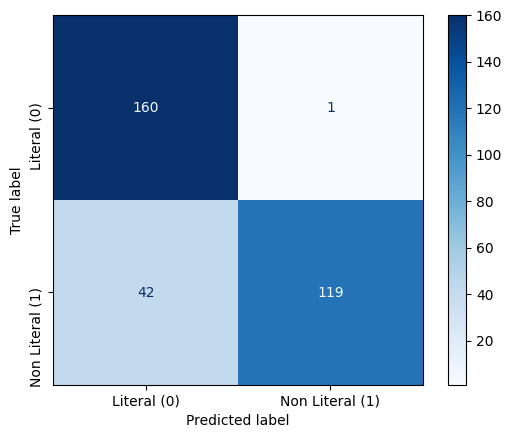

In [24]:
# Assuming targets are the true labels and final_outputs are the predicted labels
y_true_cb = np.array(targets)
y_pred_cb = np.array(final_outputs)

class_labels = ["Literal (0)", "Non Literal (1)"]

# Compute confusion matrix
cm = confusion_matrix(y_true_cb, y_pred_cb)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap="Blues")

plt.yticks(rotation=90)

plt.show()

In [25]:
print(train_df.head())
print(test_df.head())

                   FOS                                         Word Sense  \
0  magpalapad og papel           aron magbaton ug dungog sa buhat sa uban   
1  magpalapad og papel           aron magbaton ug dungog sa buhat sa uban   
2  murag namiya og tai  Usa ka tawo nga mibiya sa dili-iasa nga walay ...   
3  murag namiya og tai  Usa ka tawo nga mibiya sa dili-iasa nga walay ...   
4              makawat                                 mahimong ma-stolen   

             Verb                                              Usage  Is FOS  
0  ['magpalapad']  Ang iyang kauban sa trabaho pirmi magpalapad o...       1  
1  ['magpalapad']  Nagpalit siya og balayronon sa papel sa tindah...       0  
2              []  "Ang silingan murag namiya og tai, kalit lang ...       1  
3              []  Ang bata nagdali sa pagdagan kay murag namiya ...       0  
4     ['makawat']  Si Pedro makawat kaayo, dali ra siya madala bi...       1  
                               FOS  \
0                     ana

In [26]:
# Select relevant features
text_features_train = train_df[['FOS', 'Word Sense', 'Verb', 'Usage']].astype(str)
labels_train = train_df['Is FOS']
text_features_test = test_df[['FOS', 'Word Sense', 'Verb', 'Usage']].astype(str)
labels_test = test_df['Is FOS']

In [27]:
# Convert text features into numerical vectors using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
train_data = vectorizer.fit_transform(text_features_train.apply(lambda x: ' '.join(x), axis=1))
test_data = vectorizer.transform(text_features_test.apply(lambda x: ' '.join(x), axis=1))

In [28]:
# Hyperparameter tuning for SVM
svm_params = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
svm_grid = GridSearchCV(SVC(), svm_params, cv=5, scoring='f1')
svm_grid.fit(train_data, labels_train)
svm_best = svm_grid.best_estimator_

In [29]:
# Hyperparameter tuning for Random Forest
rf_params = {'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='f1')
rf_grid.fit(train_data, labels_train)
rf_best = rf_grid.best_estimator_

In [30]:
# Train SVM Model
svm_best.fit(train_data, labels_train)
y_pred_svm = svm_best.predict(test_data)

In [31]:
# Train Best Random Forest Model
rf_best.fit(train_data, labels_train)
y_pred_rf = rf_best.predict(test_data)

In [32]:
# Metrics Formulas
# Accuracy = (TN + TP) / (TN + FP + TP + FN)
# Precision = TP / (TP + FP)
# Recall = TP / (TP + FN)
# F1-Score = 2 * (Precision * Recall) / (Precision + Recall)

In [33]:
# Evaluation for SVM
'''accuracy_svm = accuracy_score(labels_test, y_pred_svm)
precision_svm = precision_score(labels_test, y_pred_svm)
recall_svm = recall_score(labels_test, y_pred_svm)
f1_svm = f1_score(labels_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(labels_test, y_pred_svm)

print("SVM Model:")
print(f'Accuracy: {accuracy_svm:.4f}')
print(f'Precision: {precision_svm:.4f}')
print(f'Recall: {recall_svm:.4f}')
print(f'F1-Score: {f1_svm:.4f}')
print('Classification Report:\n', classification_report(labels_test, y_pred_svm))
print('Confusion Matrix:\n', conf_matrix_svm)'''

'accuracy_svm = accuracy_score(labels_test, y_pred_svm)\nprecision_svm = precision_score(labels_test, y_pred_svm)\nrecall_svm = recall_score(labels_test, y_pred_svm)\nf1_svm = f1_score(labels_test, y_pred_svm)\nconf_matrix_svm = confusion_matrix(labels_test, y_pred_svm)\n\nprint("SVM Model:")\nprint(f\'Accuracy: {accuracy_svm:.4f}\')\nprint(f\'Precision: {precision_svm:.4f}\')\nprint(f\'Recall: {recall_svm:.4f}\')\nprint(f\'F1-Score: {f1_svm:.4f}\')\nprint(\'Classification Report:\n\', classification_report(labels_test, y_pred_svm))\nprint(\'Confusion Matrix:\n\', conf_matrix_svm)'

In [34]:
# Evaluation for Random Forest
'''accuracy_rf = accuracy_score(labels_test, y_pred_rf)
precision_rf = precision_score(labels_test, y_pred_rf)
recall_rf = recall_score(labels_test, y_pred_rf)
f1_rf = f1_score(labels_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(labels_test, y_pred_rf)

print("Random Forest Model:")
print(f'Accuracy: {accuracy_rf:.4f}')
print(f'Precision: {precision_rf:.4f}')
print(f'Recall: {recall_rf:.4f}')
print(f'F1-Score: {f1_rf:.4f}')
print('Classification Report:\n', classification_report(labels_test, y_pred_rf))
print('Confusion Matrix:\n', conf_matrix_rf)'''

'accuracy_rf = accuracy_score(labels_test, y_pred_rf)\nprecision_rf = precision_score(labels_test, y_pred_rf)\nrecall_rf = recall_score(labels_test, y_pred_rf)\nf1_rf = f1_score(labels_test, y_pred_rf)\nconf_matrix_rf = confusion_matrix(labels_test, y_pred_rf)\n\nprint("Random Forest Model:")\nprint(f\'Accuracy: {accuracy_rf:.4f}\')\nprint(f\'Precision: {precision_rf:.4f}\')\nprint(f\'Recall: {recall_rf:.4f}\')\nprint(f\'F1-Score: {f1_rf:.4f}\')\nprint(\'Classification Report:\n\', classification_report(labels_test, y_pred_rf))\nprint(\'Confusion Matrix:\n\', conf_matrix_rf)'

In [35]:
# Evaluation Metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
svm_scores = [
    accuracy_score(labels_test, y_pred_svm),
    precision_score(labels_test, y_pred_svm),
    recall_score(labels_test, y_pred_svm),
    f1_score(labels_test, y_pred_svm)
]
rf_scores = [
    accuracy_score(labels_test, y_pred_rf),
    precision_score(labels_test, y_pred_rf),
    recall_score(labels_test, y_pred_rf),
    f1_score(labels_test, y_pred_rf)
]

# Confusion Matrices
svm_cm = confusion_matrix(labels_test, y_pred_svm)
rf_cm = confusion_matrix(labels_test, y_pred_rf)

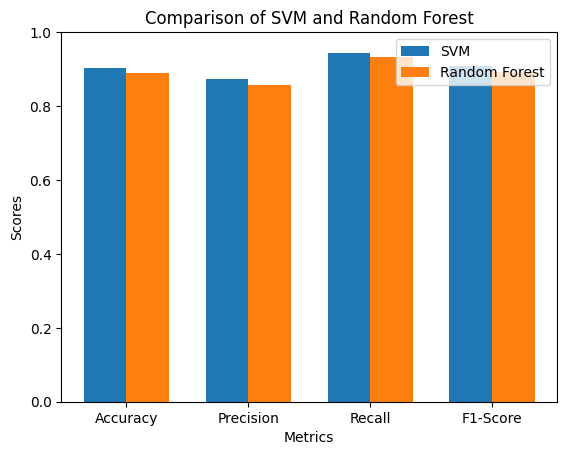

In [36]:
# Plotting the comparison
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, svm_scores, width, label='SVM')
rects2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest')

ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Comparison of SVM and Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
plt.ylim(0, 1)
plt.show()

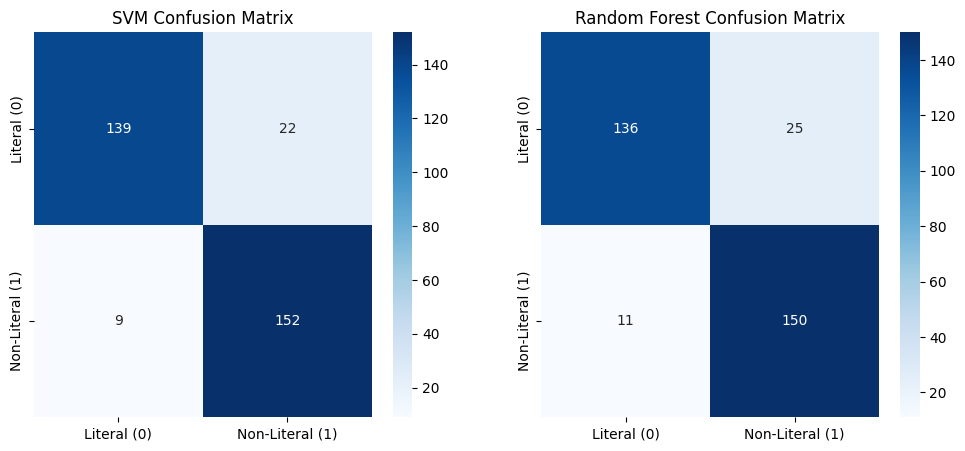

In [37]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Literal (0)', 'Non-Literal (1)'], yticklabels=['Literal (0)', 'Non-Literal (1)'], ax=axes[0])
axes[0].set_title('SVM Confusion Matrix')
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Literal (0)', 'Non-Literal (1)'], yticklabels=['Literal (0)', 'Non-Literal (1)'], ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
plt.show()

In [40]:
# Function for user input
# def classify_sentence(sentence, model):
#     sentence_vector = vectorizer.transform([sentence])
#     prediction = model.predict(sentence_vector)[0]
#     return prediction

def classify_sentence(sentence, model):
    if model == model1:  # CBERT Model
        outputs = test_model(sentence)
        return 1 if outputs >= 0.5 else 0
    else:  # SVM or Random Forest
        sentence_vector = vectorizer.transform([sentence])
        prediction = model.predict(sentence_vector)[0]
        return prediction

In [41]:
# User input and output
while True:
    user_input = input("Enter a sentence (or type 'exit' to quit): ")
    if user_input.lower() == 'exit':
        break
    print("Choose Model: 1 for SVM, 2 for Random Forest, 3 for CBERT")
    model_choice = input("Enter model number: ")
    if model_choice == '1':
        prediction = classify_sentence(user_input, svm_best)
    elif model_choice == '2':
        prediction = classify_sentence(user_input, rf_best)
    elif model_choice == '3':
        prediction = classify_sentence(user_input, model1)
    else:
        print("Invalid choice. Defaulting to SVM.")
        prediction = classify_sentence(user_input, svm_best)
    label = "Non-Literal (1)" if prediction == 1 else "Literal (0)"
    print(f'{label}')

Enter a sentence (or type 'exit' to quit): Mamatay nako
Choose Model: 1 for SVM, 2 for Random Forest, 3 for CBERT
Enter model number: 3


Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


Literal (0)
Enter a sentence (or type 'exit' to quit): Nagpalit ko og prutas sa merkado. 
Choose Model: 1 for SVM, 2 for Random Forest, 3 for CBERT
Enter model number: 3
Literal (0)
Enter a sentence (or type 'exit' to quit): Nagpalit ko og prutas sa merkado. 
Choose Model: 1 for SVM, 2 for Random Forest, 3 for CBERT
Enter model number: 1
Literal (0)
Enter a sentence (or type 'exit' to quit): Nagpalit ko og prutas sa merkado. 
Choose Model: 1 for SVM, 2 for Random Forest, 3 for CBERT
Enter model number: 2
Literal (0)
Enter a sentence (or type 'exit' to quit): exit
